<h1>Feature Engineering</h1>

Three main methods for feature engineering: Filter methods, Wrapper Functions, Embedded Methods.

<h2>Filter Methods</h2> Filter methods prior to model fitting based on criteria 
Advantages: Simpliest method, computationally inexpensive, work on any type of model

Disadvantages: Do not account for multivariate relationships, model performance is not accounted for.

Examples: Variance analysis, correllation

<h2>Wrapper functions</h2>  Subset of features are used and applied to a model and evaluated, the most optimal subset is then found using a search algorithm.

Advantages: Accounts for model performance, able to account for multivariate realtionships

Disadvantages: Computationally expensive

Examples: Forward/backward/bidirectional sequential feature selection, recursive feature selection.

<h2>Embedded Methods</h2>Different subsets of features are selected and used as model fitting occurs.

Advantages: Takes model performance into an account, less computationally expensive than Wrapper Functions.

Disadvantages: Still computationally expensive as multiple models are fit.

Examples: Ridge-Lasso regularisaton, tree based feature importance

In [3]:
import pandas as pd
import sklearn.feature_selection

In [4]:
# Creating a synthetic dataset

df = pd.DataFrame(data={
    'edu_goal': ['bachelors', 'bachelors', 'bachelors', 'masters', 'masters', 'masters', 'masters', 'phd', 'phd', 'phd'],
    'hours_study': [1, 2, 3, 3, 3, 4, 3, 4, 5, 5],
    'hours_TV': [4, 3, 4, 3, 2, 3, 2, 2, 1, 1],
    'hours_sleep': [10, 10, 8, 8, 6, 6, 8, 8, 10, 10],
    'height_cm': [155, 151, 160, 160, 156, 150, 164, 151, 158, 152],
    'grade_level': [8, 8, 8, 8, 8, 8, 8, 8, 8, 8],
    'exam_score': [71, 72, 78, 79, 85, 86, 92, 93, 99, 100]
})

display(df)

,edu_goal,hours_study,hours_TV,hours_sleep,height_cm,grade_level,exam_score
0,bachelors,1,4,10,155,8,71
1,bachelors,2,3,10,151,8,72
2,bachelors,3,4,8,160,8,78
3,masters,3,3,8,160,8,79
4,masters,3,2,6,156,8,85
5,masters,4,3,6,150,8,86
6,masters,3,2,8,164,8,92
7,phd,4,2,8,151,8,93
8,phd,5,1,10,158,8,99
9,phd,5,1,10,152,8,100


Aim to predict how well a student scores on an exam. Target variable <code>exam_score</code> and features everything else

In [5]:
# Create dataframe of features X
X = df.drop(columns=["exam_score"])
display(X)

,edu_goal,hours_study,hours_TV,hours_sleep,height_cm,grade_level
0,bachelors,1,4,10,155,8
1,bachelors,2,3,10,151,8
2,bachelors,3,4,8,160,8
3,masters,3,3,8,160,8
4,masters,3,2,6,156,8
5,masters,4,3,6,150,8
6,masters,3,2,8,164,8
7,phd,4,2,8,151,8
8,phd,5,1,10,158,8
9,phd,5,1,10,152,8


In [6]:
# Create matrix of target variable 
y = df["exam_score"]
display(y)

0     71
1     72
2     78
3     79
4     85
5     86
6     92
7     93
8     99
9    100
Name: exam_score, dtype: int64

In [7]:
# Dropping columns that are not numerical - encoding could be done alt
X_num = X.drop(columns=["edu_goal"])
display(X_num)

from sklearn.feature_selection import VarianceThreshold
feature_selector = VarianceThreshold(threshold=0)

print(feature_selector.fit_transform(X_num))

# Applying the get_support method to maintain indicies of the features
num_cols = list(X_num.columns[feature_selector.get_support(indices=True)])
print(num_cols)

# Subset to only retain the columns we want from above
X_num = X_num[num_cols]
print(X_num)

# Adding the edu_goal back into the df
X = X[['edu_goal'] + num_cols]
print(X)


,hours_study,hours_TV,hours_sleep,height_cm,grade_level
0,1,4,10,155,8
1,2,3,10,151,8
2,3,4,8,160,8
3,3,3,8,160,8
4,3,2,6,156,8
5,4,3,6,150,8
6,3,2,8,164,8
7,4,2,8,151,8
8,5,1,10,158,8
9,5,1,10,152,8


[[  1   4  10 155]
 [  2   3  10 151]
 [  3   4   8 160]
 [  3   3   8 160]
 [  3   2   6 156]
 [  4   3   6 150]
 [  3   2   8 164]
 [  4   2   8 151]
 [  5   1  10 158]
 [  5   1  10 152]]
['hours_study', 'hours_TV', 'hours_sleep', 'height_cm']
   hours_study  hours_TV  hours_sleep  height_cm
0            1         4           10        155
1            2         3           10        151
2            3         4            8        160
3            3         3            8        160
4            3         2            6        156
5            4         3            6        150
6            3         2            8        164
7            4         2            8        151
8            5         1           10        158
9            5         1           10        152
    edu_goal  hours_study  hours_TV  hours_sleep  height_cm
0  bachelors            1         4           10        155
1  bachelors            2         3           10        151
2  bachelors            3         

The result of applying the variance_threshold method means <code>grade_level</code> was dropped since there is no variance in the values for this feature - it does not add anything to the model.

<h1>Pearsons Correlation</h1> To find the correlation between two numeric, continous variables. It can be used to find the correlation between feature variables or between a feature variable and the target variable.

For two feature variables that are highly correllated with eachother - it makes sense to only maintain one of them to prevent duplicate information.



<Axes: >

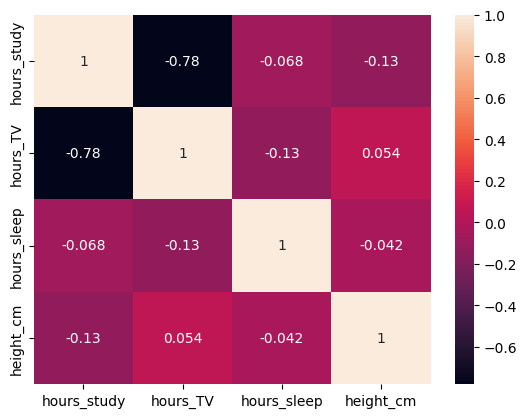

In [8]:
import matplotlib as plt
import seaborn as sns

corr_matrix = X_num.corr()

sns.heatmap(corr_matrix, annot=True)

<code>hours_tv</code> and <code>hours_study are both highly correlated with eachother. More time spent watching tv --> less time studying. Only one of these feature variables need to be selected.

For a high dimension dataset it makes sense to use a loop to go through each of the correlation and extract ones that are considered high, those greater than 0.7

In [9]:
for i in range(len(corr_matrix)):
    for j in range(i):
    # Print variables with high correlation
      if abs(corr_matrix.iloc[i, j]) > 0.7:
        print(corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j])

# Correlation between target variable and feature
X_y = X_num.copy()
X_y['exam_score'] = y
print(X_y)

hours_TV hours_study -0.780763315142435
   hours_study  hours_TV  hours_sleep  height_cm  exam_score
0            1         4           10        155          71
1            2         3           10        151          72
2            3         4            8        160          78
3            3         3            8        160          79
4            3         2            6        156          85
5            4         3            6        150          86
6            3         2            8        164          92
7            4         2            8        151          93
8            5         1           10        158          99
9            5         1           10        152         100


<Axes: >

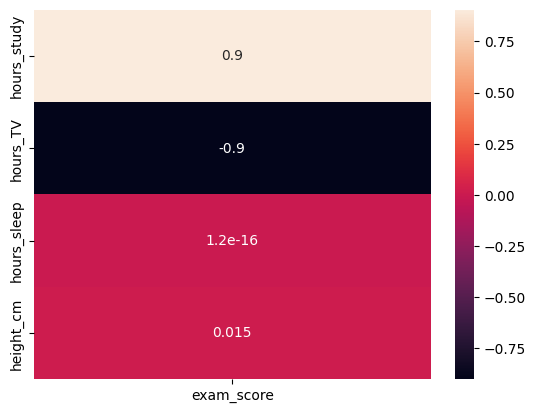

In [10]:
# Isolate the feature variable of interest and target variable
corr_matrix = X_y.corr()

# Isolate the column corresponding to `exam_score`
corr_target = corr_matrix[['exam_score']].drop(labels=['exam_score'])

sns.heatmap(corr_target, annot=True)

<code>hours_study</code> is positively correlated with <code>exam_score</code> and <code>hours_TV</code> is negatively correlated with it. It makes sense that <code>hours_study</code> and <code>hours_TV</code> would be negatively correlated with each other as seen earlier, and just one of those features would suffice for predicting <code>exam_score</code>. Since <code>hours_study</code> has a stronger correlation with the target variable, drop <code>hours_TV</code> as the redundant feature.

<code>hours_sleep</code> amd <code>height_cm</code> are not correlated with <code>exam_score</code>. Before removing them also other methods are employed to check for non-linear relationships between features and target variables.

In [11]:
X = X.drop(columns=['hours_TV'])
print(X)

    edu_goal  hours_study  hours_sleep  height_cm
0  bachelors            1           10        155
1  bachelors            2           10        151
2  bachelors            3            8        160
3    masters            3            8        160
4    masters            3            6        156
5    masters            4            6        150
6    masters            3            8        164
7        phd            4            8        151
8        phd            5           10        158
9        phd            5           10        152


<h1>Mutual Information</h1>

Used to rank and select the top features. it is a measure of dependence between two variables and gauge how much a feature contributes to the prediction of the target variable. It is no limited to linear associations. Categorical variables need to be encoded ahead of time. 

In [18]:
# Encoding the edu_goal feature
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X_enc = X.copy()
X_enc['edu_goal'] =  le.fit_transform(X['edu_goal'])

print(X_enc)
# 0 = bachelors, 1 = masters, 2 = phd

# Computing the mutual information
from sklearn.feature_selection import mutual_info_regression
print(mutual_info_regression(X_enc, y, discrete_features=[0], random_state=68))

# Selecting the best features
from sklearn.feature_selection import SelectKBest
from functools import partial

score_func = partial(mutual_info_regression, discrete_features=[0], random_state=68)

selection = SelectKBest(score_func=score_func, k = 3)
print(selection.fit_transform(X_enc, y))

# Adding the labels to the columns 
X = X[X.columns[selection.get_support(indices=True)]]
print(X)

   edu_goal  hours_study  hours_sleep
0         0            1           10
1         0            2           10
2         0            3            8
3         1            3            8
4         1            3            6
5         1            4            6
6         1            3            8
7         2            4            8
8         2            5           10
9         2            5           10
[0.81396825 0.32563492 0.03396825]
[[ 0  1 10]
 [ 0  2 10]
 [ 0  3  8]
 [ 1  3  8]
 [ 1  3  6]
 [ 1  4  6]
 [ 1  3  8]
 [ 2  4  8]
 [ 2  5 10]
 [ 2  5 10]]
    edu_goal  hours_study  hours_sleep
0  bachelors            1           10
1  bachelors            2           10
2  bachelors            3            8
3    masters            3            8
4    masters            3            6
5    masters            4            6
6    masters            3            8
7        phd            4            8
8        phd            5           10
9        phd            5           

<h1>Conclusion</h1>
6 features have been reduced to two - the most important in the sense they have the most predictive power.